In [76]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
f_sig = "../coffea/AllInOne_2022/AllInOne.coffea"

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
[19139. 27565. 22602. 16820. 12524. 21804.  7186.  4342.  2570.  1416.
   793.   452.   670.]


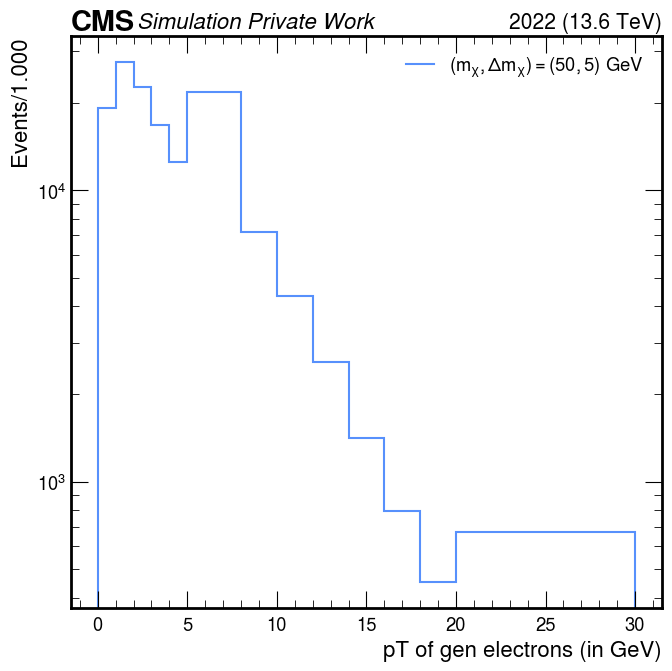

In [78]:
fig, ax = plt.subplots(figsize=(7,7))

delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_ele_pt',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "pT of gen electrons (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}



#signal points
m1=50
# m1s=[10,30,50]
delta =0.1
ctau =10



counts,edges=    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
 

counts = np.array(counts)     # shape: (n_m1, n_bins)
edges  = np.array(edges)      # shape: (n_m1, n_edges)

# counts, edges = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


mask = counts != 0

bins_x = (edges[:-1] + edges[1:])*(0.5)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)


print (counts_nonzero_den )
# avg_den = np.mean(counts_nonzero_den, axis=0)
# print("average=", avg_den)


# total = np.sum(counts_nonzero_den)
# print ("TOTAL number of gen electrons:", total)


Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png


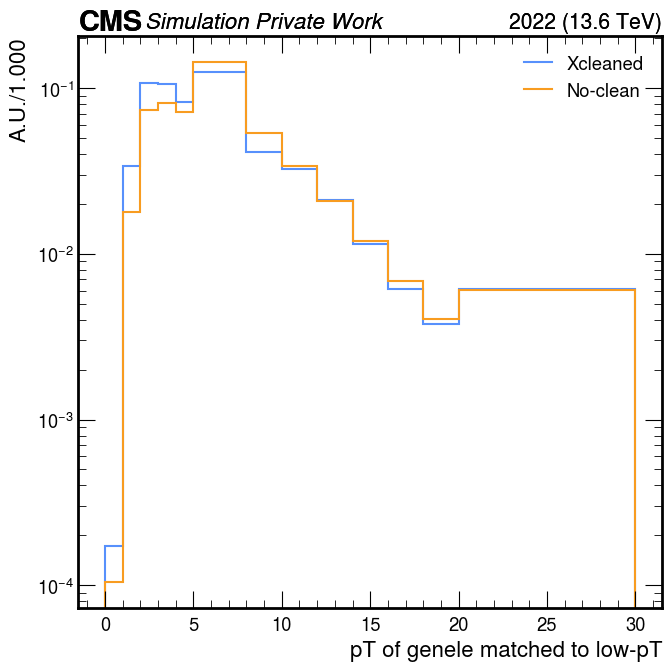

In [79]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'pT_genElePos_Lpt', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': 'Xcleaned'  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=50
delta =0.1
ctau =10


counts_xcleaned,edges_xcleaned=    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


counts_xcleaned = np.array(counts_xcleaned)     # shape: (n_m1, n_bins)
edges_xcleaned  = np.array(edges_xcleaned)      # shape: (n_m1, n_edges)


bins_x_xcleaned = (edges_xcleaned[:-1] + edges_xcleaned[1:])*(0.5)


################################################################################################################################



plot_dict = {'variable': 'pT_genElePos_Lpt_Noxclean', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': 'No-clean'  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}


#signal points
m1s=50
delta =0.1
ctau =10


counts_noxcleaned,edges_noxcleaned=    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)



counts_noxcleaned = np.array(counts_noxcleaned)     # shape: (n_m1, n_bins)
edges_noxcleaned  = np.array(edges_noxcleaned)      # shape: (n_m1, n_edges)


bins_x_noxcleaned = (edges_noxcleaned[:-1] + edges_noxcleaned[1:])*(0.5)



Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png


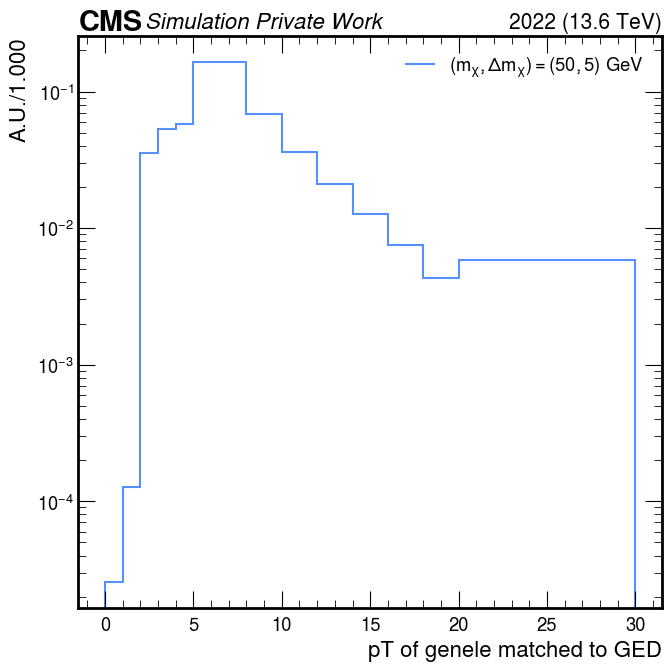

In [80]:
fig, ax = plt.subplots(figsize=(7,7))



plot_dict = {'variable': 'pT_genElePos_GED', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to GED",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=50
delta =0.1
ctau =10


counts_GED, edges_GED = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


counts_GED = np.array(counts_GED)     # shape: (n_m1, n_bins)
edges_GED  = np.array(edges_GED)      # shape: (n_m1, n_edges)


bins_x_GED = (edges_GED[:-1] + edges_GED[1:])*(0.5)



# avg_num_GED = np.mean(counts_GED, axis=0)
# print("average=", avg_num_GED)


In [81]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_noxclean, unc_eff_noxclean = eff_determine_unc(counts_noxcleaned, counts_nonzero_den)
print ("efficiency_noxclean:",len(efficiency_noxclean))

efficiency_xcleaned, unc_eff_xcleaned = eff_determine_unc(counts_xcleaned, counts_nonzero_den)
print ("efficiency_xcleaned:",efficiency_xcleaned)

efficiency_GED, unc_eff_GED = eff_determine_unc(counts_GED, counts_nonzero_den)
print ("efficiency_GED:",efficiency_GED)

# #Total= GED +Xcleaned LPt
# total_lpt_GED = efficiency_GED + efficiency_xcleaned
# print ("Total=", total_lpt_GED)

efficiency_noxclean: 13
efficiency_xcleaned: [3.65745337e-04 4.99183748e-02 1.93655429e-01 2.53745541e-01
 2.66129032e-01 2.32938910e-01 2.32396326e-01 3.01934592e-01
 3.31517510e-01 3.28389831e-01 3.15258512e-01 3.36283186e-01
 3.71641791e-01]
efficiency_GED: [5.22493338e-05 1.81389443e-04 6.18971772e-02 1.24375743e-01
 1.80613223e-01 2.95083471e-01 3.74895630e-01 3.27498848e-01
 3.17509728e-01 3.49576271e-01 3.70744010e-01 3.73893805e-01
 3.40298507e-01]


In [82]:
#Total Eff

#Numerator = number of gen matched to GED + number of gen matched to lpt (xcleaned case)
Numerator = counts_GED + counts_xcleaned

eff_total_rec, unc_eff_rec = eff_determine_unc(Numerator, counts_nonzero_den)
print ("Total Eff=", eff_total_rec)


Total Eff= [4.17994671e-04 5.00997642e-02 2.55552606e-01 3.78121284e-01
 4.46742255e-01 5.28022381e-01 6.07291957e-01 6.29433441e-01
 6.49027237e-01 6.77966102e-01 6.86002522e-01 7.10176991e-01
 7.11940299e-01]


In [83]:
print ("bins_x_noxcleaned=", len(bins_x_noxcleaned))
print ("bins_x_xcleaned=", bins_x_xcleaned)
print ("bins_x_GED=", bins_x_GED)

bins_x_noxcleaned= 13
bins_x_xcleaned= [ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  25. ]
bins_x_GED= [ 0.5  1.5  2.5  3.5  4.5  6.5  9.  11.  13.  15.  17.  19.  25. ]


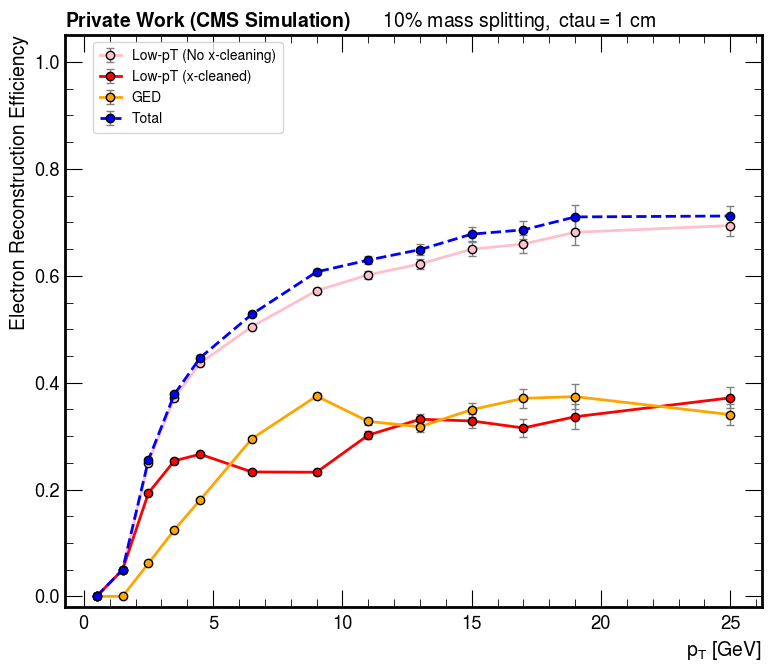

In [84]:
plt.figure(figsize=(8,7))

plt.errorbar(
    bins_x_noxcleaned,
    efficiency_noxclean,
    yerr=unc_eff_noxclean,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='pink',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (No x-cleaning)'
)

plt.errorbar(
    bins_x_xcleaned,
    efficiency_xcleaned,
    yerr=unc_eff_xcleaned,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='red',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (x-cleaned)'
)

plt.errorbar(
    bins_x_GED,
    efficiency_GED,
    yerr=unc_eff_GED,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='orange',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='GED'
)

plt.errorbar(
    bins_x_GED,
    eff_total_rec,
    yerr=unc_eff_rec,
    fmt='o--',
    linewidth=2,
    markersize=6,
    color='blue',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Total'
)
# Axis styling
plt.ylim(-0.02, 1.05)
plt.xlabel(r"$p_T$ [GeV]", fontsize=14)
plt.ylabel("Electron Reconstruction Efficiency", fontsize=14)



# Grid helps readability
# plt.grid(True, linestyle='--', alpha=0.4)

# Better title formatting


# plt.title(
    
#     r"$10\%\ \mathrm{mass\ splitting},\ c\tau = 10\ \mathrm{mm}$",
#     fontsize=18
# )

plt.title(r"$\bf{Private\ Work\ (CMS\ Simulation)} \qquad \mathrm{10\% \ mass\ splitting,\ ctau = 1\ cm}$",
          fontsize=14, loc='left')

# plt.legend(fontsize=10, frameon=True, loc='upper left')

plt.legend(
    fontsize=10,
    frameon=True,
    loc='upper left',
    bbox_to_anchor=(0.03, 1)
)

plt.tight_layout()

plt.savefig("L_lxy_ERE.png", dpi=300)